In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
})

BASE_DIR = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-')
BJCTA_PATH = BASE_DIR / 'bjcta_para.csv'
ECOLANE_PATH = BASE_DIR / 'Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx'

# Data Characterization at Different Levels

This notebook follows the basic-information style used in `data_analysis_pattern.ipynb` and summarizes both BJCTA paratransit records and the Ecolane reservation/trip workbook.

In [9]:
def _first_existing(columns, candidates):
    for col in candidates:
        if col in columns:
            return col
    return None


def summarize_dataset(df, name, date_col=None, status_col=None, customer_col=None, purpose_col=None, trip_id_col=None):
    date_col = date_col or _first_existing(df.columns, ['Trip Date', 'Date', 'Service Date'])
    status_col = status_col or _first_existing(df.columns, ['Trip Status', 'Status'])
    customer_col = customer_col or _first_existing(df.columns, ['Customer Number', 'Client ID', 'Customer ID'])
    purpose_col = purpose_col or _first_existing(df.columns, ['Purpose', 'Trip Purpose'])
    trip_id_col = trip_id_col or _first_existing(df.columns, ['Trip ID', 'Reservation ID'])

    print(f'{name}')
    print(f"Rows: {len(df):,}")
    print(f"Columns: {df.shape[1]:,}")
    memory_mb = df.memory_usage(index=False, deep=True).sum() / 1024**2
    print(f"Memory usage: {memory_mb:,.2f} MB")

    if trip_id_col:
        print(f"Unique {trip_id_col}: {df[trip_id_col].nunique(dropna=True):,}")
    if customer_col:
        print(f"Unique {customer_col}: {df[customer_col].nunique(dropna=True):,}")
    if date_col:
        dates = pd.to_datetime(df[date_col], errors='coerce')
        print(f"{date_col} valid values: {dates.notna().sum():,}")
        if dates.notna().any():
            print(f"{date_col} range: {dates.min().date()} to {dates.max().date()}")
    if status_col:
        status_clean = df[status_col].astype(str).str.strip().str.lower()
        completed = status_clean.isin(['comp', 'completed']).sum()
        cancelled = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
        noshow = status_clean.isin(['noshow', 'no show', 'no-show']).sum()
        print(f"Completed trips: {completed:,}")
        print(f"Cancelled trips: {cancelled:,}")
        print(f"No-show trips: {noshow:,}")
    if purpose_col:
        purposes = sorted(df[purpose_col].dropna().astype(str).unique())
        print(f"Purpose types ({len(purposes)}): {purposes[:30]}" + (' ...' if len(purposes) > 30 else ''))

    print(f"Columns: {list(df.columns)}")
    return df.head(3)


def column_profile(df):
    profile = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing': df.isna().sum(),
        'missing_rate': df.isna().mean(),
        'unique_values': df.nunique(dropna=True),
    })
    return profile.sort_values(['missing_rate', 'unique_values'], ascending=[False, False])


def status_table(df, status_col='Trip Status'):
    if status_col not in df.columns:
        return pd.DataFrame()
    out = (
        df[status_col]
        .astype(str)
        .str.strip()
        .value_counts(dropna=False)
        .rename_axis(status_col)
        .reset_index(name='trips')
    )
    out['share'] = out['trips'] / len(df)
    return out


def purpose_status_table(df, purpose_col='Purpose', status_col='Trip Status'):
    if purpose_col not in df.columns or status_col not in df.columns:
        return pd.DataFrame()
    status = df[status_col].astype(str).str.strip().str.lower()
    temp = df.assign(
        _purpose=df[purpose_col].where(df[purpose_col].notna(), '<missing>'),
        _completed=status.isin(['comp', 'completed']),
        _cancelled=status.isin(['cancel', 'canceled', 'cancelled']),
        _noshow=status.isin(['noshow', 'no show', 'no-show']),
    )
    out = temp.groupby('_purpose').agg({
        status_col: 'size',
        '_completed': 'sum',
        '_cancelled': 'sum',
        '_noshow': 'sum',
    })
    out = out.rename(columns={
        status_col: 'total_trips',
        '_completed': 'completed_trips',
        '_cancelled': 'cancelled_trips',
        '_noshow': 'noshow_trips',
    })
    out.index.name = purpose_col
    out['completed_rate'] = out['completed_trips'] / out['total_trips']
    return out.sort_values(['completed_rate', 'total_trips'], ascending=[False, False])


def monthly_trip_counts(df, date_col='Trip Date'):
    if date_col not in df.columns:
        return pd.DataFrame()
    dates = pd.to_datetime(df[date_col], errors='coerce')
    return (
        dates.dropna()
        .dt.to_period('M')
        .value_counts()
        .sort_index()
        .rename_axis('month')
        .reset_index(name='trips')
    )

## 1 - Load & Parse Data: `bjcta_para.csv`

In [10]:
bjcta = pd.read_csv(BJCTA_PATH)
summarize_dataset(bjcta, 'BJCTA paratransit CSV')

BJCTA paratransit CSV
Rows: 165,891
Columns: 27
Memory usage: 186.05 MB
Unique Trip ID: 165,891
Unique Customer Number: 1,432
Trip Date valid values: 113,613
Trip Date range: 2022-06-01 to 2023-02-28
Completed trips: 91,414
Cancelled trips: 63,968
No-show trips: 10,509
Purpose types (6): ['Dialysis', 'General', 'Medical', 'Other', 'School', 'Work']
Columns: ['Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'Earliest Pick-up', 'Latest Drop-off Time', 'Requested Drop-off Time', 'Run ID', 'Latest Pick-up Time', 'Scheduled Pick-up Arrival Time', 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode', 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode', 'Purpose', 'pickup_address', 'dropoff_address', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon', 'idx']


,Customer Number,Trip ID,Trip Date,Trip Status,Cancel Agent,Cancel Time,Cancel Type,Earliest Pick-up,Latest Drop-off Time,Requested Drop-off Time,Run ID,Latest Pick-up Time,Scheduled Pick-up Arrival Time,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,Drop-off Street,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,idx
0,5294,350962,6/1/22,comp,NaN,NaN,NaN,4:11,4:55,5:00,103,NaN,NaN,44th Ave N,3110,35207.0,3rd Ave S,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011,0
1,3321,346579,6/1/22,comp,NaN,NaN,NaN,4:12,4:55,5:00,104,NaN,NaN,65th St S,6905,35212.0,Richard Arrington Jr Blvd S,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409,1
2,5906,350156,6/1/22,comp,NaN,NaN,NaN,4:16,4:55,5:00,103,NaN,NaN,59th St S,204,35212.0,3rd Ave S,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011,2


In [11]:
column_profile(bjcta).head(30)

,dtype,non_null,missing,missing_rate,unique_values
Latest Drop-off Time,object,13033,152858,0.921436,953
Requested Drop-off Time,object,46056,119835,0.722372,215
Cancel Type,object,53304,112587,0.678681,13
Cancel Time,object,74436,91455,0.551296,26720
Cancel Agent,object,74436,91455,0.551296,1624
Trip Date,object,113613,52278,0.315135,234
Run ID,object,148265,17626,0.106250,61
Scheduled Pick-up Arrival Time,object,152844,13047,0.078648,95452
Latest Pick-up Time,object,152858,13033,0.078564,1019
Drop-off Zipcode,float64,165122,769,0.004636,35


In [12]:
display(status_table(bjcta))
display(purpose_status_table(bjcta).style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

,Trip Status,trips,share
0,comp,91414,0.551049
1,cancel,63968,0.385603
2,noshow,10509,0.063349


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
School,"14,474","9,760","4,082",632,67.43%
Work,"46,350","29,186","14,865","2,299",62.97%
Dialysis,"29,251","18,131","8,455","2,665",61.98%
Other,"19,787","9,516","8,959","1,312",48.09%
General,"33,865","15,412","16,347","2,106",45.51%
Medical,"22,164","9,409","11,260","1,495",42.45%


,month,trips
0,2022-06,13033
1,2022-07,11863
2,2022-08,13998
3,2022-09,14483
4,2022-10,12644
5,2022-11,13016
6,2022-12,11538
7,2023-01,11429
8,2023-02,11609


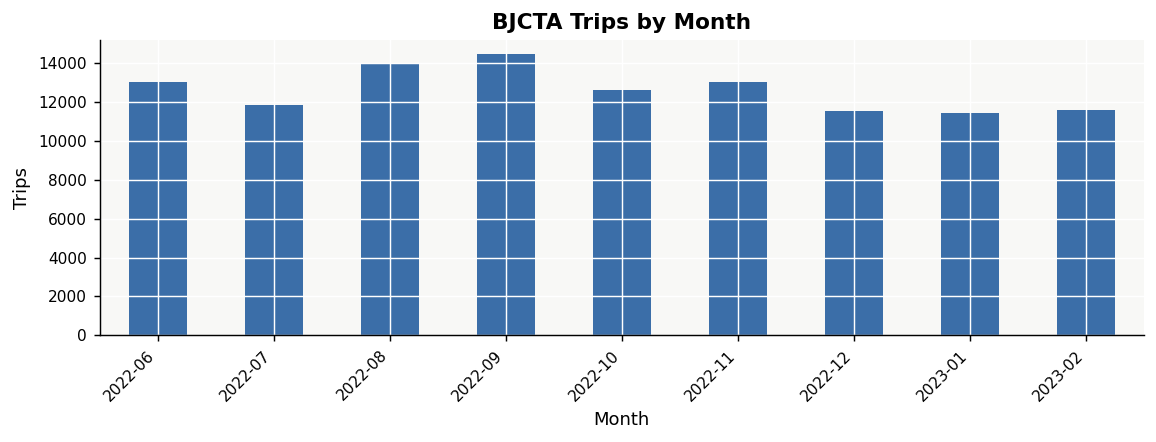

In [13]:
bjcta_monthly = monthly_trip_counts(bjcta)
display(bjcta_monthly)

ax = bjcta_monthly.assign(month=lambda x: x['month'].astype(str)).plot(
    x='month', y='trips', kind='bar', figsize=(9, 3.5), legend=False, color='#3b6ea8'
)
ax.set_title('BJCTA Trips by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Trips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## 2 - Load & Parse Data: Ecolane Reservation and Trip Workbook

In [14]:
ecolane_xls = pd.ExcelFile(ECOLANE_PATH)
print(f'Workbook sheets: {ecolane_xls.sheet_names}')

ecolane = pd.read_excel(ECOLANE_PATH, sheet_name='SMART Trip Data')
summarize_dataset(ecolane, 'Ecolane reservation and trip data')

Workbook sheets: ['SMART Trip Data']
Ecolane reservation and trip data
Rows: 121,281
Columns: 101
Memory usage: 343.04 MB
Unique Trip ID: 121,281
Unique Customer Number: 1,052
Trip Date valid values: 121,281
Trip Date range: 2022-07-01 to 2023-06-30
Completed trips: 63,841
Cancelled trips: 54,121
No-show trips: 3,319
Purpose types (10): ['Dialysis', 'Education', 'Employment', 'Medical', 'Nutrition', 'Personal', 'Recreation', 'Shopping', 'Trolley', 'Workshop']
Columns: ['Customer Number', 'Client Age', 'Edit Agent', 'Edit Timestamp', 'Trip ID', 'Trip Date', 'Trip Status', 'Mobility Device', 'Subscription Number', 'Reservation Agent', 'Order Time', 'Other Passengers', 'PCA', 'Companions', 'Children', 'Total Passengers', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'No Show Reason', 'Cluster ID', 'Pick-up OTP (minutes)', 'Vehicle Requirement', 'Direct Estimated Distance', 'Wheelchair Count', 'Direct Estimated Duration', 'Promised Pick-up Time', 'Promised Drop-off Time', 'Earliest Pick-up

,Customer Number,Client Age,Edit Agent,Edit Timestamp,Trip ID,Trip Date,Trip Status,Mobility Device,Subscription Number,Reservation Agent,Order Time,Other Passengers,PCA,Companions,Children,Total Passengers,Cancel Agent,Cancel Time,Cancel Type,No Show Reason,Cluster ID,Pick-up OTP (minutes),Vehicle Requirement,Direct Estimated Distance,Wheelchair Count,Direct Estimated Duration,Promised Pick-up Time,Promised Drop-off Time,Earliest Pick-up,Latest Pick-up Time,Earliest Drop-off Time,Latest Drop-off Time,Loading Duration,Pick-up Stop Odometer,Drop-off Stop Odometer,Unloading Duration,Negotiation Window Minus,Negotiation Window Plus,Travel Alone,Trip Act. OB-time (minutes),Trip Group Name,Trip Reported Mileage,Use Target Runs,Target Run 1,Target Run 2,Target Run 3,Run Company,Scheduled Pick-up Arrival Time,Scheduled Pick-up Departure Time,Scheduled Pick-up Duration,Pick-up Note,Pick-up Phone,Requested Pick-up Time,Reported Pick-up Arrival Time,Reported Pick-up Departure Time,Pick-up City,Pick-up County,Pick-up Latitude,Pick-up Longitude,Pick-up POI Name,Pick-up State,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,Scheduled Drop-Off Arrival Time,Scheduled Drop-Off Departure Time,Scheduled Drop-Off Duration,Drop-off City,Drop-off County,Drop-off Latitude,Drop-off Longitude,Drop-off POI Name,Drop-off State,Drop-off Street,Drop-off Street Number,Drop-off Zipcode,Drop-off Note,Drop-off Phone,Requested Drop-off Time,Reported Drop-Off Arrival Time,Reported Drop-Off Departure Time,Purpose,Funding Source,Final Client Co-pay,Final Client Co-pay Received,Additional Passenger Fare,Additional Passenger Fare Received,Fare Distance,Fare Distance Rounded Miles,Fare Type 1,Fare Type 1: quantity,Fare Type 2,Fare Type 2: quantity,Fare Type 3,Fare Type 3: quantity,Actual Trip Distance,Actual Trip Duration,Run ID,Vehicle Company,Vehicle ID,Transportation Provider
0,23083,55.0,NaN,NaT,286854,2022-07-01,cancel,cane,4152.0,sub,2022-06-17 01:45:51,0,No,0,0,1,tgriswold,2022-06-22 06:45:37,Renegotiation,NaN,616634.0,NaN,NaN,9.38,0,11.37,05:22:00,05:49:00,05:07:00,05:35:00,05:24:00,05:49:00,3.0,NaN,NaN,2,30.0,0.0,No,NaN,NaN,NaN,Mandatory,Finch,NaN,NaN,ClasTran,2022-07-01 05:22:24,2022-07-01 05:25:24,3.0,NaN,2056672663,NaN,NaN,NaN,Leeds,Jefferson,33.543593,-86.572576,NaN,AL,Forest Way,407,35094.0,2022-07-01 05:36:46,2022-07-01 05:38:46,2.0,Irondale,Jefferson,33.531577,-86.715948,FRESENIUS KIDNEY CARE MONTCLAIR,AL,Ludington Ln,7780,35210.0,NaN,NaN,05:54:00,NaN,NaN,Dialysis,JCCELDI,4.0,NaN,0.0,NaN,9.33,9,Cash,1.0,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,ClasTran
1,14909,60.0,cmcneal,2022-07-06 09:45:55,286738,2022-07-01,comp,cane,2599.0,sub,2022-06-17 01:45:43,0,No,0,0,1,NaN,NaT,NaN,NaN,625850.0,-18.92,NaN,14.31,0,19.83,05:45:00,NaN,05:30:00,06:00:00,05:30:00,06:48:00,3.0,152869.00,152884.00,2,0.0,30.0,No,21.35,NaN,15.00,Mandatory,E&I-102,NaN,NaN,Ebony & Ivory,2022-07-01 05:45:41,2022-07-01 05:48:41,3.0,NaN,NaN,05:15:00,05:26:00,05:28:00,Birmingham,Jefferson,33.603306,-86.711765,NaN,Al,Glynn Dr,308,35215.0,2022-07-01 05:48:08,2022-07-01 05:50:08,2.0,Birmingham,Jefferson,33.475050,-86.823489,Immigration Office,AL,Beacon Pkwy W,529,35209.0,NaN,NaN,NaN,05:49:00,05:49:00,Employment,JCCELDI,4.0,4.0,0.0,0.0,12.48,12,Cash,1.0,NaN,NaN,NaN,NaN,14.31,22.97,E&I-102,Ebony & Ivory,3799,Ebony & Ivory
2,6712,75.0,NaN,NaT,286886,2022-07-01,comp,none,4221.0,sub,2022-06-17 01:45:53,0,No,0,0,1,NaN,NaT,NaN,NaN,625299.0,39.55,NaN,10.29,0,12.18,06:15:00,NaN,06:00:00,06:30:00,06:00:00,07:03:00,3.0,130246.06,130256.35,2,0.0,30.0,No,19.03,NaN,10.29,Mandatory,Finch,NaN,NaN,ClasTran,2022-07-01 06:15:00,2022-07-01 06:18:00,3.0,NaN,2057021828,06:00:00,06:54:00,07:04:00,Leeds,Jefferson,33.546257,-86.558513,NaN,Al,Chattanooga St,1520,35094.0,2022-07-01 07:17:06,2022-07-01 07:19:06,2.0,Irondale,Jefferson,33.531577,-86.715948,FRESENIUS KIDNEY CARE MONTCLAIR,AL,Ludington Ln,7780,35210.0,NaN,NaN,NaN,07:23:00,07:32:00,Dialysis,JCCELDI,4.0,4.0,0.0,0.0,10.24,10,Cash,1.0,NaN,NaN,NaN,NaN,10.29,37.

In [15]:
column_profile(ecolane).head(40)

,dtype,non_null,missing,missing_rate,unique_values
Target Run 3,float64,0,121281,1.000000,0
Fare Type 3,float64,0,121281,1.000000,0
Fare Type 3: quantity,float64,6,121275,0.999951,1
Target Run 2,object,204,121077,0.998318,18
Fare Type 2,object,1526,119755,0.987418,4
Fare Type 2: quantity,float64,1784,119497,0.985290,17
Edit Timestamp,datetime64[ns],1815,119466,0.985035,1815
Edit Agent,object,1815,119466,0.985035,4
No Show Reason,object,3209,118072,0.973541,6
Drop-off Note,object,12021,109260,0.900883,474


In [16]:
display(status_table(ecolane))
display(purpose_status_table(ecolane).style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

,Trip Status,trips,share
0,comp,63841,0.526389
1,cancel,54121,0.446245
2,noshow,3319,0.027366


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
,245,245,0,0,100.00%
Trolley,12,12,0,0,100.00%
Dialysis,"13,186","7,851","5,078",257,59.54%
Workshop,"5,511","3,204","2,245",62,58.14%
Education,"1,526",878,634,14,57.54%
Employment,"13,619","7,818","5,582",219,57.41%
Nutrition,"64,285","36,847","25,229","2,209",57.32%
Recreation,"1,001",409,554,38,40.86%
Shopping,"2,192",668,"1,492",32,30.47%


In [17]:
summary_cols = [
    'Client Age', 'Other Passengers', 'PCA', 'Companions', 'Children', 'Total Passengers',
    'Direct Estimated Distance', 'Direct Estimated Duration', 'Actual Trip Distance',
    'Actual Trip Duration', 'Pick-up OTP (minutes)', 'Negotiation Window Minus',
    'Negotiation Window Plus', 'Fare Distance', 'Final Client Co-pay'
]
numeric_cols = [col for col in summary_cols if col in ecolane.columns]
ecolane[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Client Age,119558.0,65.901746,19.584790,11.0,57.00,70.00,80.00,357.00
Other Passengers,121281.0,0.006192,0.212574,0.0,0.00,0.00,0.00,12.00
Companions,121281.0,0.078273,4.758888,0.0,0.00,0.00,0.00,636.00
Children,121281.0,0.001014,0.059743,0.0,0.00,0.00,0.00,10.00
Total Passengers,121281.0,1.120975,4.770117,1.0,1.00,1.00,1.00,637.00
Direct Estimated Distance,121281.0,7.254367,6.914308,0.0,2.42,4.68,10.50,62.33
Direct Estimated Duration,121281.0,14.028318,11.222313,0.0,6.10,10.35,19.67,102.70
Actual Trip Distance,121281.0,5.517711,8.380075,0.0,0.00,1.63,8.52,150.49
Actual Trip Duration,121281.0,18.519734,25.274181,0.0,0.00,6.85,31.12,436.53
Pick-up OTP (minutes),70357.0,-0.408097,23.257629,-480.0,-14.78,-2.93,11.43,410.78


,month,trips
0,2022-07,9211
1,2022-08,10524
2,2022-09,10372
3,2022-10,10375
4,2022-11,9336
5,2022-12,9149
6,2023-01,10847
7,2023-02,9614
8,2023-03,11044
9,2023-04,9553


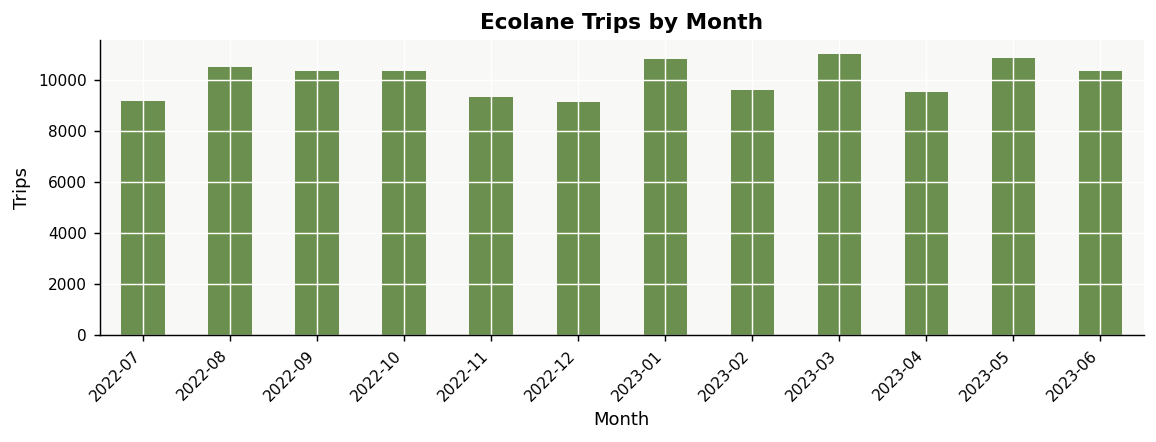

In [18]:
ecolane_monthly = monthly_trip_counts(ecolane)
display(ecolane_monthly)

ax = ecolane_monthly.assign(month=lambda x: x['month'].astype(str)).plot(
    x='month', y='trips', kind='bar', figsize=(9, 3.5), legend=False, color='#6a8f4e'
)
ax.set_title('Ecolane Trips by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Trips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## 3 - Cross-Dataset Snapshot

In [19]:
def dataset_snapshot(df, name):
    dates = pd.to_datetime(df['Trip Date'], errors='coerce') if 'Trip Date' in df.columns else pd.Series(dtype='datetime64[ns]')
    status = df['Trip Status'].astype(str).str.strip().str.lower() if 'Trip Status' in df.columns else pd.Series(dtype=object)
    return {
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'unique_customers': df['Customer Number'].nunique() if 'Customer Number' in df.columns else np.nan,
        'unique_trips': df['Trip ID'].nunique() if 'Trip ID' in df.columns else np.nan,
        'date_min': dates.min().date() if dates.notna().any() else pd.NaT,
        'date_max': dates.max().date() if dates.notna().any() else pd.NaT,
        'completed_trips': status.isin(['comp', 'completed']).sum() if len(status) else np.nan,
        'cancelled_trips': status.isin(['cancel', 'canceled', 'cancelled']).sum() if len(status) else np.nan,
        'noshow_trips': status.isin(['noshow', 'no show', 'no-show']).sum() if len(status) else np.nan,
    }

pd.DataFrame([
    dataset_snapshot(bjcta, 'bjcta_para.csv'),
    dataset_snapshot(ecolane, 'Ecolane SMART Trip Data'),
]).style.format({
    'rows': '{:,.0f}',
    'columns': '{:,.0f}',
    'unique_customers': '{:,.0f}',
    'unique_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
})

,dataset,rows,columns,unique_customers,unique_trips,date_min,date_max,completed_trips,cancelled_trips,noshow_trips
0,bjcta_para.csv,"165,891",27,"1,432","165,891",2022-06-01,2023-02-28,"91,414","63,968","10,509"
1,Ecolane SMART Trip Data,"121,281",101,"1,052","121,281",2022-07-01,2023-06-30,"63,841","54,121","3,319"
